In [1]:
# %% ── CELL 1: Imports & environment ─────────────────────────────────────────
%matplotlib inline
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys, os
 
# ── paths ──
CAFPYANA_WD = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."          # directory containing nue_helpers.py / nue_selection.py
PLOT_DIR     = "./nuecc_plots"
MC_FILE      = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20.df"
TARGET_POT   = 6.6e20
TITLE        = "SBND $\\nu_e$ CC Inclusive"
 
os.makedirs(PLOT_DIR, exist_ok=True)
 
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)
 
import pyanalib.split_df_helpers as splh
import nue_helpers   as nh
import nue_selection as ns
 
%load_ext autoreload
%autoreload 2
 
print("matplotlib backend:", plt.get_backend())
print("All imports OK ✓")
 

matplotlib backend: inline
All imports OK ✓


In [2]:
import os
import pandas as pd

print("=== MC_FILE diagnostics ===")
print(f"MC_FILE = {MC_FILE!r}")
print(f"File exists?          {os.path.exists(MC_FILE)}")
print(f"File size (bytes)     {os.path.getsize(MC_FILE) if os.path.exists(MC_FILE) else 'N/A'}")
print(f"Is file?              {os.path.isfile(MC_FILE)}")

try:
    with pd.HDFStore(MC_FILE, mode='r') as store:
        print(f"Available keys:       {store.keys()}")
        print(f"Number of keys:       {len(store.keys())}")
except Exception as e:
    print(f"Error opening HDFStore: {e}")

=== MC_FILE diagnostics ===
MC_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20.df'
File exists?          True
File size (bytes)     20129614364
Is file?              True
Available keys:       ['/evt_0', '/evt_1', '/evt_10', '/evt_11', '/evt_12', '/evt_13', '/evt_14', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/evt_7', '/evt_8', '/evt_9', '/hdr_0', '/hdr_1', '/hdr_10', '/hdr_11', '/hdr_12', '/hdr_13', '/hdr_14', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/hdr_7', '/hdr_8', '/hdr_9', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_10', '/histgenevtdf_11', '/histgenevtdf_12', '/histgenevtdf_13', '/histgenevtdf_14', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histgenevtdf_6', '/histgenevtdf_7', '/histgenevtdf_8', '/histgenevtdf_9', '/histpotdf_0', '/histpotdf_1', '/histpotdf_10', '/histpotdf_11', '/histpotdf_12', '/histpotdf_13', '/histpotdf_14', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5'

In [3]:
# %% ── CELL 2: Load DataFrames & POT ─────────────────────────────────────────
 
print("Loading evt table …")
evtdf = splh.load_dfs(MC_FILE, ["evt"])["evt"]
print(f"  shape       : {evtdf.shape}")
print(f"  index names : {evtdf.index.names}")
print(f"  top columns : {evtdf.columns.get_level_values(0).unique().tolist()}")
 
print("\nLoading mcnu table …")
mcnudf = splh.load_dfs(MC_FILE, ["mcnu"])["mcnu"]
print(f"  shape       : {mcnudf.shape}")
 
print("\nLoading POT …")
histpotdf = splh.load_dfs(MC_FILE, ["histpotdf"], n_max_concat=5)["histpotdf"]
total_pot, pot_scale = nh.compute_pot_scale(histpotdf, TARGET_POT)
print(f"  Total POT    : {total_pot:.3e}")
print(f"  Target POT   : {TARGET_POT:.3e}")
print(f"  Scale factor : {pot_scale:.3f}")
 
# ── Convenience wrappers (created once, reused everywhere) ──
rp = nh.reco_particles(evtdf)     # particle -> rec -> dlp -> particles
tp = nh.true_particles(evtdf)     # particle -> rec -> dlp_true -> particles
ri = nh.reco_interactions(evtdf)  # rec -> dlp
ti = nh.true_interactions(evtdf)  # rec -> dlp_true
 
print("\nExample access:")
print("  rp.pid.value_counts():\n", rp.pid.value_counts().head())
print("  rp[0].ke:\n", rp[0].ke.values[:5], "…")
print("  ri.vertex.x.head():\n", ri.vertex.x.head())


Loading evt table …
  shape       : (9215361, 288)
  index names : ['__ntuple', 'entry', 'rec.dlp..index', 'rec.dlp.particles..index']
  top columns : ['rec', 'rec.dlp_true..index_x', 'rec.dlp_true..index_y', 'rec.dlp_true.particles..index']

Loading mcnu table …
  shape       : (455633, 104)

Loading POT …
  Total POT    : 8.266e+18
  Target POT   : 6.600e+20
  Scale factor : 79.842

Example access:
  rp.pid.value_counts():
 pid
1    5743652
2    2299833
0     556933
4     478311
3     136632
Name: count, dtype: int64
  rp[0].ke:
 [  30.08074951  496.04309082   14.34895325 1496.28149414    9.77607727] …
  ri.vertex.x.head():
 __ntuple  entry  rec.dlp..index  rec.dlp.particles..index
8         0      0               0                           130.950012
                 1               0                          -233.850006
                                 1                          -233.850006
                                 2                          -233.850006
                   

In [4]:
cols = [" -> ".join([str(c) for c in col if c != ""]) for col in evtdf.columns]

# Determine the midpoint
mid = (len(cols) + 1) // 2
left = cols[:mid]
right = cols[mid:]

# Set a fixed width for alignment
width = max(len(c) for c in left) + 4

for l, r in zip(left, right + [""] * (len(left) - len(right))):
    print(f"{l:<{width}}{r}")

rec -> dlp -> match_ids                             rec -> dlp -> particles -> mcs_ke_per_pid -> I3
rec -> dlp -> match_overlaps                        rec -> dlp -> particles -> mcs_ke_per_pid -> I4
rec -> dlp -> cathode_offset                        rec -> dlp -> particles -> mcs_ke_per_pid -> I5
rec -> dlp -> depositions_sum                       rec -> dlp -> particles -> momentum -> x
rec -> dlp -> flash_hypo_pe                         rec -> dlp -> particles -> momentum -> y
rec -> dlp -> flash_total_pe                        rec -> dlp -> particles -> momentum -> z
rec -> dlp -> id                                    rec -> dlp -> particles -> num_fragments
rec -> dlp -> is_cathode_crosser                    rec -> dlp -> particles -> p
rec -> dlp -> is_contained                          rec -> dlp -> particles -> pdg_code
rec -> dlp -> is_fiducial                           rec -> dlp -> particles -> pid
rec -> dlp -> is_flash_matched                      rec -> dlp -> particles 

In [5]:
# %% ── CELL 3: Truth classification ──────────────────────────────────────────
 
truth_cat = ns.classify_truth(evtdf, verbose=True)
# truth_cat : pd.Series indexed by interaction MultiIndex, values 0-6 (or -1)
 
# True-signal interaction index (used for efficiency denominator)
sig_inter_idx = ns.true_signal_index(evtdf)
print(f"\nTrue nueCC-in-FV signal interactions: {len(sig_inter_idx):,}")

classify_truth: reading true-interaction flags …
  is_nu        :  316,456
  is_cc        :  250,059
  is_fv (true) :  168,405
  true_elec    :   17,250
  true_muon    : 2,303,954
  has_pi0      :   42,226

=== Truth category summary ===
  cat  0  nueCC FV (signal)     :      808
  cat  1  nueCC out FV          :      504
  cat  2  numuCC + π⁰           :   15,297
  cat  3  NC π⁰                 :   12,435
  cat  4  other numuCC          :  171,604
  cat  5  other NC              :   53,962
  cat  6  cosmic                : 2,493,974
  cat  7  other neutrino        :   61,846
  total                     : 2,810,430

True nueCC-in-FV signal interactions: 808


In [6]:
# %% ── CELL 4: Cut flow + purity / efficiency ─────────────────────────────────
 
cut_flow = ns.build_cut_flow(evtdf)
# cut_flow["single_electron"]["inter_index"]  → final selection
# cut_flow["single_electron"]["particle_mask"] → particle-level mask
 
# ── Align truth categories with interaction-level cut-flow indices ──
il = nh.inter_levels(evtdf)
 
def _inter_sel_mask(inter_idx):
    """Bool array (interaction level) matching truth_cat index."""
    return truth_cat.index.isin(inter_idx)
 
def _sig_mask():
    return truth_cat.index.isin(sig_inter_idx)
 
# Build parallel lists for pur/eff calculation
cut_masks  = [_inter_sel_mask(cut_flow[c]["inter_index"]) for c in ns.CUT_NAMES]
sig_mask   = _sig_mask()
 
# Purity / efficiency (excluding precut from purity since all events selected)
purs, effs = nh.pur_eff_cut_flow(cut_masks, sig_mask)
 
# ── Summary table ──
print(f"\n{'Cut':<26} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>10}")
print("─" * 60)
for name, label, mask, pur, eff in zip(ns.CUT_NAMES, ns.CUT_LABELS,
                                        cut_masks, purs, effs):
    n = cut_flow[name]["inter_index"].shape[0]
    p = f"{pur*100:.1f}%" if not np.isnan(pur) else "—"
    e = f"{eff*100:.1f}%" if not np.isnan(eff) else "—"
    print(f"  {label:<24} {n:>9,}  {p:>8}  {e:>10}")

Building cut flow:   0%|          | 0/5 [00:00<?, ?it/s]


Cut                          N inter    Purity  Efficiency
────────────────────────────────────────────────────────────
  No cut                   2,810,430      0.0%      100.0%
  Flash match                251,656      0.3%       86.9%
  In FV                      144,287      0.5%       86.1%
  No primary muons            48,727      1.4%       83.9%
  Final state topology         5,121     12.7%       80.2%


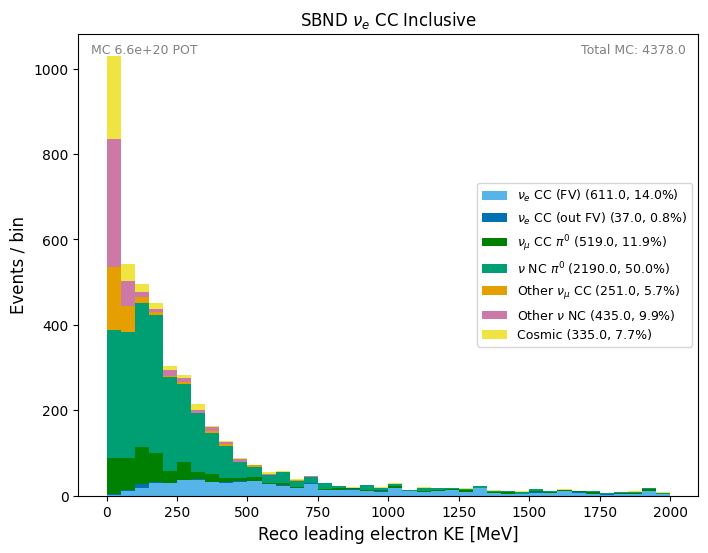

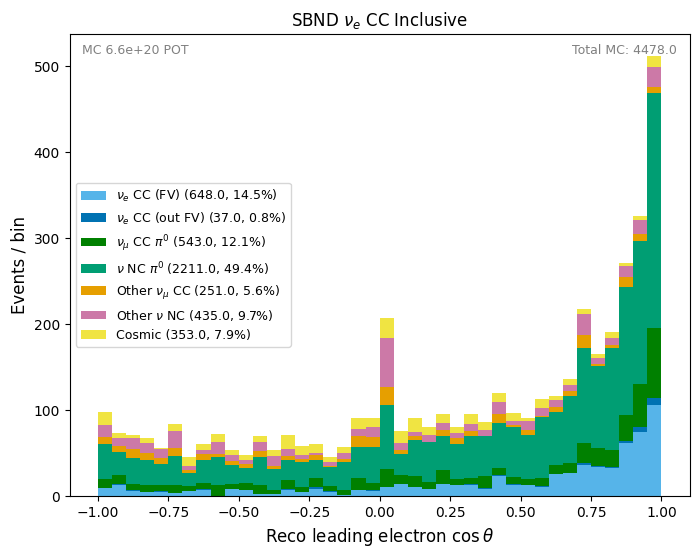

In [7]:
# %% ── CELL 5: Stacked histograms (reco KE and cos θ) ────────────────────────
 
# Use the final selection mask at particle level
final_pmask = cut_flow["single_electron"]["particle_mask"]
 
# Leading electron KE for each surviving interaction, categorised
reco_ke_all  = ns.leading_electron_ke(evtdf)   # interaction-level Series
reco_cos_all = ns.leading_electron_costheta(evtdf)
 
# Align truth categories
all_cats = sorted([c for c in nh.CAT_COLORS if c >= 0])
 
def _cat_ke_values(cat_code, sel_inter_idx):
    """reco leading-electron KE for interactions in sel_inter_idx with given category."""
    cat_inter = truth_cat[truth_cat == cat_code].index
    both = sel_inter_idx.intersection(cat_inter)
    return reco_ke_all.reindex(both).dropna().values
 
def _cat_cos_values(cat_code, sel_inter_idx):
    cat_inter = truth_cat[truth_cat == cat_code].index
    both = sel_inter_idx.intersection(cat_inter)
    return reco_cos_all.reindex(both).dropna().values
 
sel_idx = cut_flow["single_electron"]["inter_index"]
 
ke_bins  = np.linspace(0, 2000, 41)    # MeV
cos_bins = np.linspace(-1, 1, 41)
 
# ── KE plot ──
fig_ke, ax_ke = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list = [_cat_ke_values(c, sel_idx) for c in all_cats],
    labels      = [nh.CAT_LABELS[c] for c in all_cats],
    colors      = [nh.CAT_COLORS[c] for c in all_cats],
    bins        = ke_bins,
    xlabel      = "Reco leading electron KE [MeV]",
    title       = fr"{TITLE}",
    pot_label   = f"MC {TARGET_POT:.1e} POT",
    ax          = ax_ke,
)
plt.show()
nh.save_plot("reco_electron_ke", fig=fig_ke, folder_name=PLOT_DIR)
 
# ── cos θ plot ──
fig_cos, ax_cos = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list = [_cat_cos_values(c, sel_idx) for c in all_cats],
    labels      = [nh.CAT_LABELS[c] for c in all_cats],
    colors      = [nh.CAT_COLORS[c] for c in all_cats],
    bins        = cos_bins,
    xlabel      = r"Reco leading electron $\cos\theta$",
    title       = fr"{TITLE}",
    pot_label   = f"MC {TARGET_POT:.1e} POT",
    ax          = ax_cos,
)
plt.show()
nh.save_plot("reco_electron_costheta", fig=fig_cos, folder_name=PLOT_DIR)
 
 

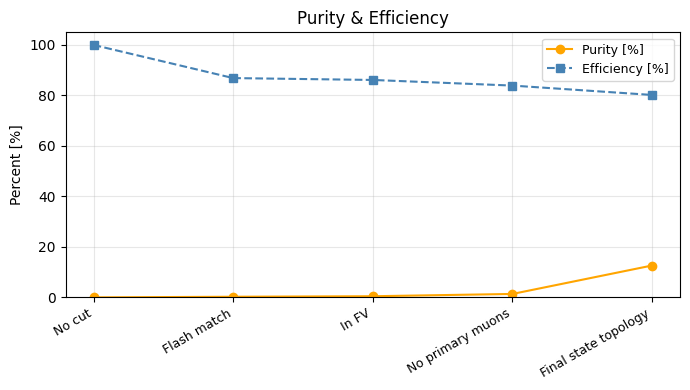

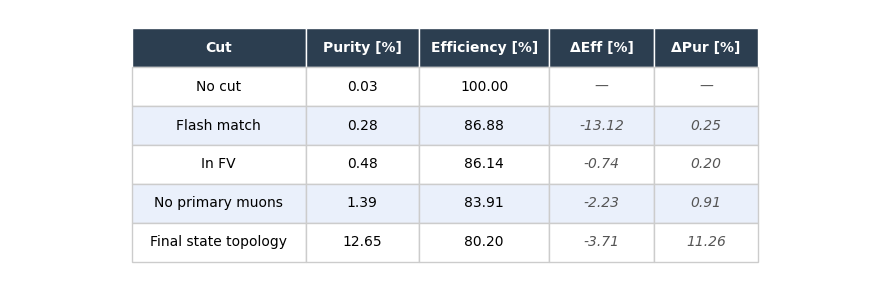

In [8]:
# %% ── CELL 6: Cut-flow table + purity/efficiency summary plot ────────────────

# ── Purity / efficiency line plot ──
fig, ax_pe = plt.subplots(figsize=(7, 4))
ax_pe.plot(ns.CUT_LABELS, [p * 100 for p in purs], "o-",  color="orange",    label="Purity [%]")
ax_pe.plot(ns.CUT_LABELS, [e * 100 for e in effs], "s--", color="steelblue", label="Efficiency [%]")
ax_pe.set_ylim(0, 105)
ax_pe.set_xticks(range(len(ns.CUT_LABELS)))
ax_pe.set_xticklabels(ns.CUT_LABELS, rotation=30, ha="right", fontsize=9)
ax_pe.set_ylabel("Percent [%]")
ax_pe.set_title("Purity & Efficiency")
ax_pe.legend(fontsize=9)
ax_pe.grid(alpha=0.3)

plt.tight_layout()
plt.show()
nh.save_plot("cutflow_pur_eff", fig=fig, folder_name=PLOT_DIR)

# ── Numeric table via matplotlib ──
fig_tab, ax_tab = plt.subplots(figsize=(9, 3))
nh.create_purity_efficiency_table(purs, effs, ns.CUT_LABELS, ax_tab)
fig_tab.tight_layout()
plt.show()
nh.save_plot("cutflow_table", fig=fig_tab, folder_name=PLOT_DIR)

=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 19,639
Raw min  : 9.6096
Raw max  : 33956.8484
Raw mean : 488.7439
Raw median: 268.8330
After *1000 (GeV→MeV)  → min/max: 9609.6 – 33956848.4 MeV
After *1     (already MeV) → min/max: 9.6 – 33956.8 MeV


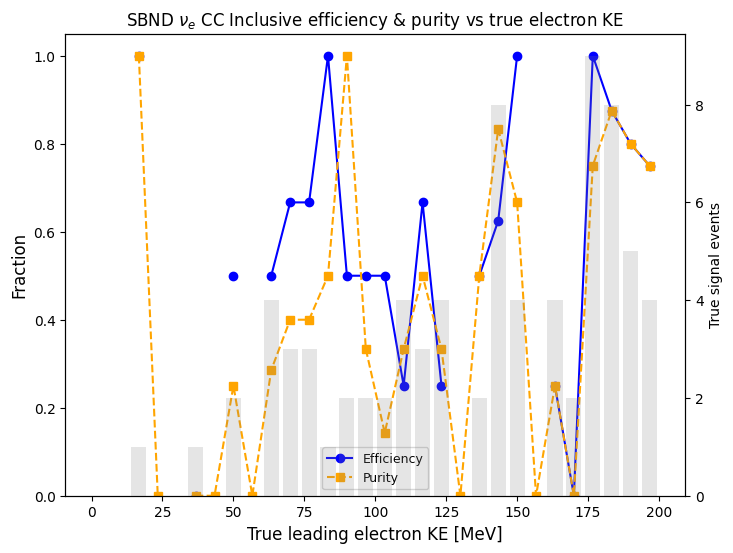

All cells complete. Plots saved to: ./nuecc_plots


In [9]:
# %% ── CELL 7: Binned efficiency & purity vs true electron KE ─────────────────
true_ke_all = ns.true_leading_electron_ke(evtdf)
common_idx  = truth_cat.index
true_ke_arr = true_ke_all.reindex(common_idx).values

sig_arr = common_idx.isin(sig_inter_idx)
sel_arr = common_idx.isin(cut_flow["single_electron"]["inter_index"])

# ── Customisable binning ───────────────────────────────────────────────────────
xbin_range = (0, 200)   # <── set your KE range here  [MeV]
xbin_count = 30          # <── number of bins
# ─────────────────────────────────────────────────────────────────────────────

ke_bins_t = np.linspace(xbin_range[0], xbin_range[1], xbin_count + 1)
centers, purs_b, effs_b, counts_b = nh.pur_eff_binned(
    values   = true_ke_arr,
    bins     = ke_bins_t,
    sel_mask = sel_arr,
    sig_mask = sig_arr,
)

fig_bin, ax_bin = plt.subplots(figsize=(8, 6))
ax2 = ax_bin.twinx()
nh.plot_eff_pur_vs_bin(
    bin_centers  = centers,
    purs         = purs_b,
    effs         = effs_b,
    counts_true  = counts_b,
    xlabel       = "True leading electron KE [MeV]",
    title        = fr"{TITLE} efficiency & purity vs true electron KE",
    ax           = ax_bin,
    ax2          = ax2,
)
plt.show()
nh.save_plot("binned_eff_pur_ke", fig=fig_bin, folder_name=PLOT_DIR)
print("All cells complete. Plots saved to:", PLOT_DIR)

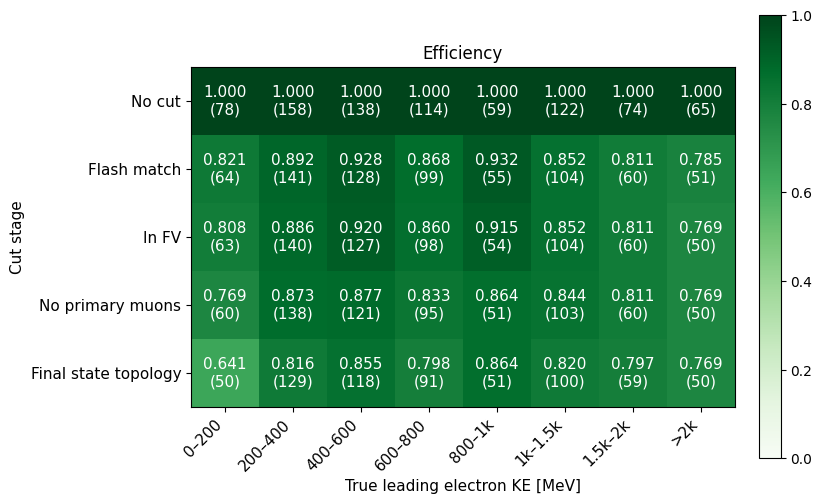

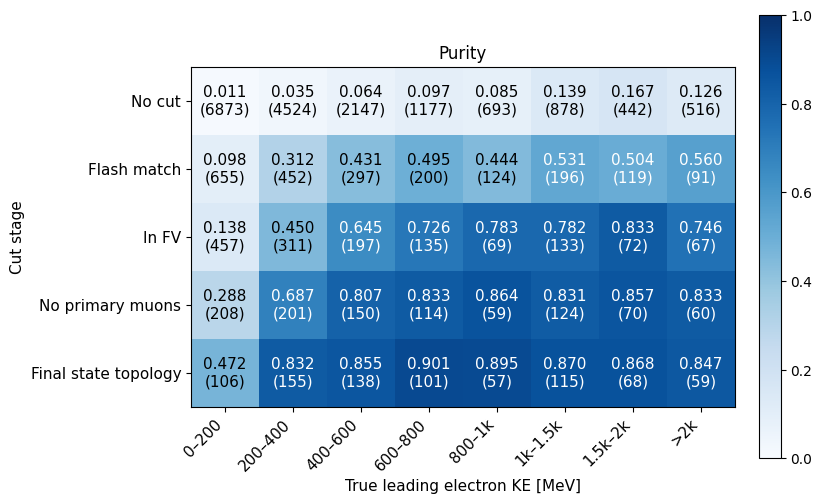

In [10]:
# %% ── CELL 8: Efficiency & purity matrices (KE bins × cut stages) ────────────
ke_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]
n_bins = len(ke_bins_c) - 1
n_cuts = len(ns.CUT_NAMES)

# Align true KE to the common interaction index
true_ke_aligned = true_ke_all.reindex(common_idx)
sig_true_vals   = common_idx.isin(sig_inter_idx)

eff_matrix   = np.zeros((n_bins, n_cuts))
pur_matrix   = np.zeros((n_bins, n_cuts))
count_matrix = np.zeros((n_bins, n_cuts))
pur_count_matrix = np.zeros((n_bins, n_cuts))

for ci, cut_name in enumerate(ns.CUT_NAMES):
    cut_idx = cut_flow[cut_name]["inter_index"]
    reco_sel = common_idx.isin(cut_idx)

    _, purs_i, effs_i, total_sig_in_bin = nh.pur_eff_binned(
        values  = true_ke_aligned.fillna(-999).values,
        bins    = ke_bins_c,
        sel_mask = reco_sel,
        sig_mask = sig_true_vals,
    )

    selected_sig_in_bin   = np.zeros(n_bins)
    selected_total_in_bin = np.zeros(n_bins)
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin = (true_ke_aligned.fillna(-999).values >= lo) & \
                 (true_ke_aligned.fillna(-999).values < hi)
        selected_sig_in_bin[i]   = (in_bin & sig_true_vals & reco_sel).sum()
        selected_total_in_bin[i] = (in_bin & reco_sel).sum()          # ← new

    eff_matrix[:, ci] = np.nan_to_num(effs_i)
    pur_matrix[:, ci] = np.nan_to_num(purs_i)
    count_matrix[:, ci]     = selected_sig_in_bin    # for efficiency: sig passed
    pur_count_matrix[:, ci] = selected_total_in_bin  # for purity: total selected

for mat, count_mat, title, cmap, fname in [
    (eff_matrix, count_matrix,     "Efficiency", "Greens", "eff_matrix_true_ke_vs_cuts"),
    (pur_matrix, pur_count_matrix, "Purity",     "Blues",  "pur_matrix_true_ke_vs_cuts"),
]:
    fig, ax = nh.plot_matrix_binned(
        mat, count_mat,                              # ← pass the right one
        bin_values        = np.arange(n_bins),
        bin_labels        = ke_bin_labels,
        cut_labels        = ns.CUT_LABELS,
        remove_dummy_col  = False,
        xlabel            = "True leading electron KE [MeV]",
        title             = title,
        cmap              = cmap,
    )
    fig.tight_layout()
    nh.save_plot(fname, fig=fig, folder_name=PLOT_DIR)

In [11]:
# %% ── CELL 2: Cut flow ──────────────────────────────────────────────────────
cut_flow = ns.build_cut_flow(evtdf)
 
for stage in ns.CUT_NAMES:
    if stage in cut_flow:
        print(f"  {stage:<20s}  {len(cut_flow[stage]['inter_index']):>8,} interactions")
 
 
# %% ── CELL 3: Truth classification & signal denominator ─────────────────────
truth_cat    = ns.classify_truth(evtdf)
sig_inter_idx = ns.true_signal_index(evtdf)
print(f"\nTrue signal interactions (denominator): {len(sig_inter_idx):,}")

Building cut flow:   0%|          | 0/5 [00:00<?, ?it/s]

  precut                2,810,430 interactions
  valid_flashmatch       251,656 interactions
  fiducial               144,287 interactions
  no_muons                48,727 interactions
  single_electron          5,121 interactions
classify_truth: reading true-interaction flags …
  is_nu        :  316,456
  is_cc        :  250,059
  is_fv (true) :  168,405
  true_elec    :   17,250
  true_muon    : 2,303,954
  has_pi0      :   42,226

=== Truth category summary ===
  cat  0  nueCC FV (signal)     :      808
  cat  1  nueCC out FV          :      504
  cat  2  numuCC + π⁰           :   15,297
  cat  3  NC π⁰                 :   12,435
  cat  4  other numuCC          :  171,604
  cat  5  other NC              :   53,962
  cat  6  cosmic                : 2,493,974
  cat  7  other neutrino        :   61,846
  total                     : 2,810,430

True signal interactions (denominator): 808


In [12]:
pause

NameError: name 'pause' is not defined

In [ ]:
mc_file    = "/home/castalyf/cafpyana_out/mc1e20.df"
PLOT_DIR   = "./nuecc_plots"
TARGET_POT = 6.6e20    # scale to this POT
 
os.makedirs(PLOT_DIR, exist_ok=True)

with pd.HDFStore(mc_file, "r") as store:
    print(store.keys())

In [ ]:
print("Loading evt table...")
mc_dfs = splh.load_dfs(mc_file, ["evt"])
evtdf  = mc_dfs["evt"]
print(f"  evtdf shape : {evtdf.shape}")
print(f"  index names : {evtdf.index.names}")
print(f"  top-level columns : {evtdf.columns.get_level_values(0).unique().tolist()}")

print("\nLoading mcnu table...")
mc_dfs = splh.load_dfs(mc_file, ["mcnu"])
mcnudf  = mc_dfs["mcnu"]
print(f"  evtdf shape : {mcnudf.shape}")
print(f"  index names : {mcnudf.index.names}")
print(f"  top-level columns : {mcnudf.columns.get_level_values(0).unique().tolist()}")

 
# POT
histpotdf = splh.load_dfs(mc_file, ["histpotdf"], n_max_concat=5)["histpotdf"]
total_pot, pot_scale = nh.compute_pot_scale(histpotdf, TARGET_POT)
print(f"\n  Total POT    : {total_pot:.3e}")
print(f"  Target POT   : {TARGET_POT:.3e}")
print(f"  Scale factor : {pot_scale:.3f}")

In [ ]:
cols = [" -> ".join([str(c) for c in col if c != ""]) for col in evtdf.columns]

# Determine the midpoint
mid = (len(cols) + 1) // 2
left = cols[:mid]
right = cols[mid:]

# Set a fixed width for alignment
width = max(len(c) for c in left) + 4

for l, r in zip(left, right + [""] * (len(left) - len(right))):
    print(f"{l:<{width}}{r}")

In [ ]:
# Quick sanity checks on the loaded df

inter_levels = nh.get_inter_levels(evtdf)
print(f"Interaction index levels : {inter_levels}  → {evtdf.index.names[:-1]}")
 
# Number of unique interactions
n_interactions = evtdf.groupby(level=inter_levels).ngroups
n_particles    = len(evtdf)
print(f"Unique interactions : {n_interactions:,}")
print(f"Total particle rows : {n_particles:,}")
 
# Preview key particle-level columns
parts = evtdf["particle"]["rec"]["dlp"]["particles"]
print("\nParticle PID distribution:")
print(parts["pid"].value_counts())

In [ ]:
# save a few events into csv 

subset = evtdf.reset_index().head(100)
subset.to_csv("evtdf_preview.csv", index=False)
print("Saved: evtdf_preview.csv")

interaction_subset = (
    evtdf
    .xs((1, 0, 0), level=['__ntuple', 'entry', 'rec.dlp..index'])
    .reset_index()
)
interaction_subset.to_csv("interaction01_preview.csv", index=False)
print("Saved: interaction01_preview.csv")


export_df = pd.concat([
    evtdf["particle"]["rec"]["dlp_true"]["particles"],
    evtdf["particle"]["rec"]["dlp"]["particles"]
], axis=1).reset_index()

export_df.head(1000).to_csv("particle_preview.csv", index=False)
print("Saved: particle_preview.csv")

In [ ]:
true_electrons = evtdf[
    evtdf["particle"]["rec"]["dlp_true"]["particles"]["pid"] == 1
]
true_electrons

In [ ]:
import nue_helpers as nh

rp = nh.reco_particles(evtdf)      # reco particles
tp = nh.true_particles(evtdf)      # truth particles
ri = nh.reco_interactions(evtdf)
ti = nh.true_interactions(evtdf)

# Your preferred syntax now works:
print(rp[1].pid)                   # ← PID of every particle in interaction 1
print(rp[1][["pid", "ke", "is_primary"]])   # clean sub-table
print(tp[1].pdg_code)              # true PDG codes for interaction 1

# Full-column access still works
print(rp.pid.value_counts())       # all reco PIDs in the whole file
print(ri.is_fiducial)              # all reco interactions

In [ ]:
# Per-event weights (POT scaling)

# Weights live at interaction level — broadcast to particle level.
# For POT scaling we apply a flat scale factor to all MC events.
# If the file has per-event genweights, use those; otherwise use pot_scale.
try:
    weights_inter = (
        evtdf.groupby(level=inter_levels)
        .first()
        .get("genweight", pd.Series(1.0,
             index=evtdf.groupby(level=inter_levels).first().index))
        * pot_scale
    )
    print("Using per-event genweights × pot_scale")
except Exception:
    weights_inter = pd.Series(
        pot_scale,
        index=evtdf.groupby(level=inter_levels).first().index
    )
    print("Using flat pot_scale weight")
 
# Broadcast back to particle level
weights_particle = weights_inter.reindex(
    evtdf.index.droplevel(-1)
).values
print(f"Weights range: [{weights_particle.min():.4f}, {weights_particle.max():.4f}]")
 

In [ ]:
print("Classifying truth categories …")
truth_cat = ns.classify_truth(evtdf, verbose=True)

print("\nTruth category distribution (unweighted):")
print(truth_cat.value_counts().sort_index())

In [ ]:
signal_cat = 0
# Interaction-level signal truth mask
sig_true = (truth_cat == signal_cat)

print(f"Total interactions : {len(truth_cat):,}")
print(f"True signal (nueCC FV) : {sig_true.sum():,}")

# Diagnostic: how many true signal interactions are flash-matched?
fm_inter = ns.get_flash_matched_interactions(evtdf)
sig_and_fm = sig_true[sig_true.index.isin(fm_inter)].sum()
print(f"True signal AND flash-matched: {sig_and_fm:,} "
      f"({100*sig_and_fm/max(sig_true.sum(),1):.1f}% of signal)")

fv_inter = ns.get_fiducial_interactions(evtdf)
sig_and_fv = sig_true[sig_true.index.isin(fv_inter)].sum()
print(f"True signal AND fiducial : {sig_and_fv:,} "
      f"({100*sig_and_fv/max(sig_true.sum(),1):.1f}% of signal)")

# === ADD THIS BLOCK (or the appropriate call for your setup) ===
cut_flow = ns.build_cut_flow(evtdf)   # ←←← this is what was missing

# Weights aligned to truth_cat index
w_inter = weights_inter.reindex(truth_cat.index).fillna(pot_scale)

pur_list, eff_list = [], []
for cut_name, label in zip(ns.CUT_NAMES, ns.CUT_LABELS):
    inter_idx = cut_flow[cut_name]["inter_index"]
    reco_sel = sig_true.index.isin(inter_idx)   # bool array aligned to truth_cat
    p, e = nh.calc_pur_eff(reco_sel, sig_true.values, w_inter.values)
    pur_list.append(p)
    eff_list.append(e)
    n_sel = reco_sel.sum()
    print(f" {label:<30s}: pur={p:.3f} eff={e:.3f} n_sel={n_sel:,}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax, table = nh.create_purity_efficiency_table(pur_list, eff_list, ns.CUT_LABELS, ax)
ax.set_title("nueCC inclusive – SPINE (cut flow purity & efficiency)")
fig.tight_layout()
display(fig)
nh.save_plot("pur_eff_table_nueCC_SPINE", fig=fig, folder_name=PLOT_DIR)
plt.show(fig)

In [ ]:
# Stacked spectra at final selection

sel_pmask = cut_flow["single_electron"]["particle_mask"]
sel_inter = cut_flow["single_electron"]["inter_index"]
 
sel_cats = truth_cat[truth_cat.index.isin(sel_inter)]
 
print("Category breakdown at final selection:")
for c, n in sel_cats.value_counts().sort_index().items():
    print(f"  {c:2d} ({nh.CAT_LABELS.get(c,'?'):<22s}): {n:,}")
 
# Leading electron KE per category
lead_ke_byCat = {}
for cat in sorted(nh.CAT_LABELS.keys()):
    cat_inter = sel_cats[sel_cats == cat].index
    if len(cat_inter) == 0:
        lead_ke_byCat[cat] = pd.Series(dtype=float)
        continue
    cat_pmask = sel_pmask & evtdf.index.droplevel(-1).isin(cat_inter)
    ke = ns.leading_electron_ke(evtdf, particle_mask=cat_pmask)
    lead_ke_byCat[cat] = ke
 
true_ke_all = ns.true_electron_ke(evtdf)
print(f"\nTrue electron KE computed for {true_ke_all.notna().sum():,} interactions")

In [ ]:
ke_bins = np.linspace(0, 2000, 51)
 
series_list, labels_list, colors_list, weights_list = [], [], [], []
for cat in sorted(nh.CAT_LABELS.keys()):
    ser = lead_ke_byCat.get(cat, pd.Series(dtype=float))
    if len(ser) == 0:
        continue
    w_c = weights_inter.reindex(ser.index).fillna(pot_scale)
    series_list.append(ser.values)
    weights_list.append(w_c.values)
    labels_list.append(nh.CAT_LABELS[cat])
    colors_list.append(nh.CAT_COLORS[cat])
 
fig, ax = plt.subplots(figsize=(9, 5))
nh.plot_stacked_hist(
    series_list, labels_list, colors_list, ke_bins,
    weights=weights_list,
    xlabel="Reconstructed leading electron KE [MeV]",
    ylabel=f"Interactions / bin  ({TARGET_POT:.1e} POT)",
    title="nueCC SPINE – final selection",
    ax=ax,
    alpha=0.8,
    pot_label=f"{TARGET_POT:.2e} POT",
)
fig.tight_layout()
display(fig)
nh.save_plot("reco_lead_elec_ke_final", fig=fig, folder_name=PLOT_DIR)
plt.close(fig)

In [ ]:
# Plot: efficiency vs true electron KE
true_ke_bins = np.linspace(0, 2500, 26)
 
# Align true KE to truth_cat index
true_ke_aligned = true_ke_all.reindex(truth_cat.index)
 
# The efficiency denominator here is all true signal interactions in the df
sig_true_vals = sig_true.values
sel_reco_vals = truth_cat.index.isin(sel_inter)
 
bc_ke, purs_ke, effs_ke, counts_ke = nh.pur_eff_binned(
    true_ke_aligned.fillna(-999).values,
    true_ke_bins,
    sel_reco_vals,
    sig_true_vals,
    weights=w_inter.values,
)
 
fig, ax = plt.subplots(figsize=(9, 4))
nh.plot_eff_pur_vs_bin(
    bc_ke, purs_ke, effs_ke, counts_ke,
    xlabel="True leading electron KE [MeV]",
    title="nueCC SPINE – efficiency & purity vs. true electron KE",
    ax=ax,
)
fig.tight_layout()
display(fig)
nh.save_plot("eff_pur_vs_true_elec_ke", fig=fig, folder_name=PLOT_DIR)
plt.close(fig)
 

In [ ]:
# This mirrors section 5 of the numuCC notebook (plot_matrix_binned)
# Rows = cut steps, Columns = KE bins
ke_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]
n_bins = len(ke_bins_c) - 1
n_cuts = len(ns.CUT_NAMES)
 
eff_matrix   = np.zeros((n_bins, n_cuts))
pur_matrix   = np.zeros((n_bins, n_cuts))
count_matrix = np.zeros((n_bins, n_cuts))
 
for ci, cut_name in enumerate(ns.CUT_NAMES):
    cut_idx   = cut_flow[cut_name]["inter_index"]
    reco_sel  = truth_cat.index.isin(cut_idx)
    bc, purs_i, effs_i, cnt_i = nh.pur_eff_binned(
        true_ke_aligned.fillna(-999).values,
        ke_bins_c,
        reco_sel,
        sig_true_vals,
        weights=w_inter.values,
    )
    eff_matrix[:, ci]   = np.nan_to_num(effs_i)
    pur_matrix[:, ci]   = np.nan_to_num(purs_i)
    count_matrix[:, ci] = cnt_i
 
for mat, title, cmap, fname in [
    (eff_matrix, "Efficiency", "Greens", "eff_matrix_true_ke_vs_cuts"),
    (pur_matrix, "Purity",     "Blues",  "pur_matrix_true_ke_vs_cuts"),
]:
    fig, ax = nh.plot_matrix_binned(
        mat, count_matrix,
        bin_values=np.arange(n_bins),
        bin_labels=ke_bin_labels,
        cut_labels=ns.CUT_LABELS,
        remove_dummy_col=False,
        xlabel="True leading electron KE [MeV]",
        title=title, cmap=cmap,
    )
    fig.tight_layout()
    display(fig)
    nh.save_plot(fname, fig=fig, folder_name=PLOT_DIR)
    plt.close(fig)
 

In [ ]:
#cos(theta) efficiency
 
ct_bins = np.linspace(-1, 1, 21)
 
# True cos(theta)
true_ct_all = ns.true_electron_costheta(evtdf)
true_ct_aligned = true_ct_all.reindex(truth_cat.index)
 
bc_ct, purs_ct, effs_ct, counts_ct = nh.pur_eff_binned(
    true_ct_aligned.fillna(-999).values,
    ct_bins,
    sel_reco_vals,
    sig_true_vals,
    weights=w_inter.values,
)
 
fig, ax = plt.subplots(figsize=(9, 4))
nh.plot_eff_pur_vs_bin(
    bc_ct, purs_ct, effs_ct, counts_ct,
    xlabel=r"True $\cos\theta_e$",
    title=r"nueCC SPINE – efficiency & purity vs. true $\cos\theta_e$",
    ax=ax,
)
fig.tight_layout()
display(fig)
nh.save_plot("eff_pur_vs_true_costheta", fig=fig, folder_name=PLOT_DIR)
plt.close(fig)
 
# Stacked reco cos(theta)
ct_series_byCat = {}
for cat in sorted(nh.CAT_LABELS.keys()):
    cat_inter = sel_cats[sel_cats == cat].index
    if len(cat_inter) == 0:
        ct_series_byCat[cat] = pd.Series(dtype=float)
        continue
    cat_pmask = sel_pmask & evtdf.index.droplevel(-1).isin(cat_inter)
    try:
        ct_series_byCat[cat] = ns.leading_electron_costheta(evtdf, particle_mask=cat_pmask)
    except Exception:
        ct_series_byCat[cat] = pd.Series(dtype=float)
 
ct_sl, ct_lb, ct_co, ct_wl = [], [], [], []
for cat in sorted(nh.CAT_LABELS.keys()):
    ser = ct_series_byCat.get(cat, pd.Series(dtype=float))
    if len(ser) == 0:
        continue
    w_c = weights_inter.reindex(ser.index).fillna(pot_scale)
    ct_sl.append(ser.values); ct_wl.append(w_c.values)
    ct_lb.append(nh.CAT_LABELS[cat]); ct_co.append(nh.CAT_COLORS[cat])
 
fig, ax = plt.subplots(figsize=(9, 5))
nh.plot_stacked_hist(
    ct_sl, ct_lb, ct_co,
    bins=np.linspace(-1, 1, 21),
    weights=ct_wl,
    xlabel=r"Reconstructed $\cos\theta_e$",
    ylabel=f"Interactions / bin  ({TARGET_POT:.1e} POT)",
    title=r"nueCC SPINE – final selection",
    ax=ax, alpha=0.8,
)
fig.tight_layout()
display(fig)
nh.save_plot("reco_lead_elec_costheta_final", fig=fig, folder_name=PLOT_DIR)
plt.close(fig)

In [ ]:
## CELL 13 ────────────────────────────── Vertex distributions (reco & true)
 
# Reco vertex at final selection
try:
    vx_sel = evtdf["rec"]["dlp"]["vertex"]["x"][sel_pmask].groupby(level=inter_levels).first()
    vy_sel = evtdf["rec"]["dlp"]["vertex"]["y"][sel_pmask].groupby(level=inter_levels).first()
    vz_sel = evtdf["rec"]["dlp"]["vertex"]["z"][sel_pmask].groupby(level=inter_levels).first()
    have_vertex = True
except Exception as ex:
    print(f"Vertex read failed: {ex}")
    have_vertex = False
 
if have_vertex:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, vals, lbl, xrange in zip(
        axes,
        [vx_sel, vy_sel, vz_sel],
        [r"Vertex $x$ [cm]", r"Vertex $y$ [cm]", r"Vertex $z$ [cm]"],
        [(-210, 210), (-210, 210), (-10, 510)],
    ):
        ax.hist(vals.dropna().values, bins=40, range=xrange,
                color="#1f77b4", histtype="stepfilled", alpha=0.7)
        ax.set_xlabel(lbl)
        ax.set_ylabel("Interactions")
        ax.grid(alpha=0.3)
    fig.suptitle("nueCC SPINE – reco vertex (final selection)")
    nh.save_plot("reco_vertex_xyz_final", fig=fig, folder_name=PLOT_DIR)
    plt.show()
 
 
## CELL 14 ────────────────────────────── Flash match score distribution
 
try:
    fm_scores_raw = evtdf["rec"]["dlp"]["match_overlaps"].groupby(level=inter_levels).first()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(fm_scores_raw.dropna().values, bins=50, histtype="step", color="steelblue")
    ax.set_xlabel("Flash match overlap score")
    ax.set_ylabel("Interactions")
    ax.set_title("nueCC SPINE – flash match score (precut)")
    ax.set_yscale("log")
    nh.save_plot("flash_match_score_precut", fig=fig, folder_name=PLOT_DIR)
    plt.show()
except Exception as ex:
    print(f"Flash match score plot failed: {ex}")
 
 
## CELL 15 ────────────────────────────── PID score distributions
 
# Electron PID score (pid_scores.I1 = electron score)
try:
    pid_e_score = evtdf["particle"]["pid_scores"]["I1"]
    pid_m_score = evtdf["particle"]["pid_scores"]["I2"]   # muon
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, score, lbl in zip(axes,
                               [pid_e_score, pid_m_score],
                               ["Electron PID score (I1)", "Muon PID score (I2)"]):
        ax.hist(score.dropna().values, bins=50, range=(0, 1),
                histtype="stepfilled", alpha=0.7, color="steelblue")
        ax.set_xlabel(lbl)
        ax.set_ylabel("Particles")
        ax.grid(alpha=0.3)
    fig.suptitle("nueCC SPINE – PID scores (precut, all particles)")
    nh.save_plot("pid_scores_precut", fig=fig, folder_name=PLOT_DIR)
    plt.show()
except Exception as ex:
    print(f"PID score plot failed: {ex}")
 
 
## CELL 16 ────────────────────────────── Summary print
 
print("=" * 60)
print("nueCC SPINE analysis – summary")
print("=" * 60)
print(f"  MC file       : {mc_file}")
print(f"  Total POT     : {total_pot:.3e}")
print(f"  Target POT    : {TARGET_POT:.3e}")
print(f"  Scale factor  : {pot_scale:.4f}")
print()
print("  Cut flow (unweighted interactions):")
for cut_name, label in zip(ns.CUT_NAMES, ns.CUT_LABELS):
    n = len(cut_flow[cut_name]["inter_index"])
    print(f"    {label:<30s}: {n:>8,}")
print()
print(f"  Signal category (nueCC FV) at final selection:")
n_sig_sel = int((sel_cats == 0).sum())
print(f"    {n_sig_sel:,} interactions")
print()
print("  Plots saved to:", PLOT_DIR)

In [ ]:
import uproot
import awkward as ak
import pandas as pd
import numpy as np

def load_first_match(caf_path, particle=True):
    """
    Load match_ids and match_overlaps (first entry only) from a flat CAF.
    particle=True -> rec.dlp.particles.match_ids
    particle=False -> rec.dlp.match (slice-level)
    """
    with uproot.open(caf_path) as f:
        tree = f["recTree"]
        
        if particle:
            id_branch   = "rec.dlp.particles.match_ids"
            ovlp_branch = "rec.dlp.particles.match_overlaps"
        else:
            id_branch   = "rec.dlp.match"
            ovlp_branch = "rec.dlp.match_overlap"
        
        match_ids  = tree[id_branch].array()
        match_ovlp = tree[ovlp_branch].array()
        
        # take first element of each jagged array, NaN if empty
        first_id   = ak.to_numpy(ak.fill_none(ak.firsts(match_ids),  -1))
        first_ovlp = ak.to_numpy(ak.fill_none(ak.firsts(match_ovlp),  np.nan))
        
        return pd.DataFrame({
            "match_id":      first_id,
            "match_overlap": first_ovlp,
        })

# Usage:
caf = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/input000-reweighted.flat.caf.root"
match_df = load_first_match(caf, particle=True)
print(match_df.head())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh

# ── 1. Load the df ──────────────────────────────────────────────────────
mc_file = "/home/castalyf/cafpyana_out/mc1e20.df"
keys2load = ['evt', 'hdr', 'mcnu']
mc_dfs = splh.load_dfs(mc_file, keys2load, n_max_concat=1)

evtdf  = mc_dfs['evt']    # particle-level: one row per SPINE particle
hdrdf  = mc_dfs['hdr']    # one row per event
mcnudf = mc_dfs['mcnu']   # one row per true neutrino interaction

# ── 2. POT scaling ──────────────────────────────────────────────────────
histpotdf = splh.load_dfs(mc_file, ['histpotdf'], n_max_concat=1)['histpotdf']
total_pot  = histpotdf['TotalPOT'].sum()
target_pot = 6.6e20  # adjust to your target
pot_scale  = target_pot / total_pot
print(f"Total POT: {total_pot:.3e}, Scale factor: {pot_scale:.3f}")

# ── 3. Basic SPINE particle cuts ─────────────────────────────────────────
parts = evtdf['particle']

# primary particles only
is_primary = parts['is_primary'] == 1

# valid reconstruction
is_valid = parts['is_valid'] == 1

# contained
is_contained = parts['is_contained'] == 1

# pid: SPINE pid codes are typically
#   0=photon, 1=electron, 2=muon, 3=pion, 4=proton
pid = parts['pid']
is_electron = pid == 1
is_muon     = pid == 2
is_proton   = pid == 4

# ── 4. nueCC inclusive selection ─────────────────────────────────────────
# Interaction level: require at least one primary electron
# Group by interaction index (first two index levels = entry, interaction)
inter_levels = list(range(evtdf.index.nlevels - 1))  # all but particle level

primary_electrons = evtdf[is_primary & is_valid & is_electron]

# interactions with at least one primary electron
has_electron = primary_electrons.groupby(level=inter_levels).size() > 0

# apply to evtdf
evtdf_nueCC = evtdf[evtdf.index.droplevel(-1).isin(has_electron[has_electron].index)]

print(f"Interactions passing nueCC selection: {has_electron.sum()}")
print(f"Particles in those interactions: {len(evtdf_nueCC)}")

# ── 5. Leading electron kinematics ───────────────────────────────────────
lead_electron = (
    evtdf[is_primary & is_valid & is_electron]
    ['particle']['ke']
    .groupby(level=inter_levels)
    .max()
)

plt.figure()
plt.hist(lead_electron.dropna(), bins=50, range=(0, 2000))
plt.xlabel("Leading electron KE (MeV)")
plt.ylabel("Interactions / bin")
plt.title("nueCC: Leading electron KE")
plt.tight_layout()
plt.savefig("lead_electron_ke.png")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh

# ── 1. Load ONLY the evt (SPINE) table ───────────────────────────────────
mc_file = "/home/castalyf/cafpyana_out/mc1e20.df"
mc_dfs = splh.load_dfs(mc_file, ['evt'], n_max_concat=1)
evtdf = mc_dfs['evt']

print(f"Loaded evtdf shape: {evtdf.shape}")
print("Top-level column groups:", sorted(evtdf.columns.get_level_values(0).unique().tolist()))

# ── Helper: flatten any nested columns to clean leaf names ────────────────
def get_leaf_column_names(sub):
    """Return flat string branch names (handles pid_scores.I0, vertex.x, etc.)"""
    if isinstance(sub, pd.Series):
        return [sub.name]
    if isinstance(sub.columns, pd.MultiIndex):
        leaves = []
        for col_tuple in sub.columns.to_flat_index():
            flat = '.'.join(str(x) for x in col_tuple if x != '' and pd.notna(x))
            leaves.append(flat)
        return leaves
    else:
        return [str(c) for c in sub.columns.tolist()]

# ── 2. Load expected branches from branches.py (NOW INCLUDING TRUTH) ───────
branches_file = "/home/castalyf/cafpyana/makedf/branches.py"
with open(branches_file, 'r') as f:
    exec(f.read(), globals())  # loads ALL *branches lists including etruth*

expected_reco_inter = []
expected_reco_part = []
expected_truth_inter = []
expected_truth_part = []

for name, val in list(globals().items()):
    if name.endswith("branches") and isinstance(val, list):
        for b in val:
            if isinstance(b, str):
                if b.startswith("rec.dlp.") and ".particles." not in b and "true" not in b.lower():
                    stripped = b[len("rec.dlp."):].strip('.')
                    expected_reco_inter.append(stripped)
                elif "rec.dlp.particles." in b:
                    stripped = b.split("rec.dlp.particles.", 1)[1].strip('.')
                    expected_reco_part.append(stripped)
                elif b.startswith("rec.dlp_true."):
                    if ".particles." in b:
                        stripped = b.split("rec.dlp_true.particles.", 1)[1].strip('.')
                        expected_truth_part.append(stripped)
                    else:
                        stripped = b[len("rec.dlp_true."):].strip('.')
                        expected_truth_inter.append(stripped)

for d in (expected_reco_inter, expected_reco_part, expected_truth_inter, expected_truth_part):
    d[:] = sorted(set(d))

print(f"Expected reco interaction-level: {len(expected_reco_inter)}")
print(f"Expected reco particle-level:    {len(expected_reco_part)}")
print(f"Expected truth interaction-level:{len(expected_truth_inter)}")
print(f"Expected truth particle-level:   {len(expected_truth_part)}")

# ── 3. Detect groups & collect AVAILABLE branches (reco + truth) ──────────
particle_group = 'particle' if 'particle' in evtdf.columns.get_level_values(0) else None

# Reco interaction (everything NOT particle and NOT truth)
avail_reco_inter = set()
for g in evtdf.columns.get_level_values(0).unique():
    if g == particle_group or 'true' in str(g).lower():
        continue
    sub = evtdf[g]
    avail_reco_inter.update(get_leaf_column_names(sub))

# Reco particle
avail_reco_part = set()
if particle_group:
    sub_p = evtdf[particle_group]
    avail_reco_part = set(get_leaf_column_names(sub_p))

# Truth groups (dlp_true.*)
truth_groups = [g for g in evtdf.columns.get_level_values(0).unique() if 'true' in str(g).lower()]
print(f"→ Detected truth groups: {truth_groups or 'None (truth table not present in this CAF)'}")

avail_truth_inter = set()
avail_truth_part = set()
for g in truth_groups:
    sub = evtdf[g]
    leaves = get_leaf_column_names(sub)
    if 'particles' in str(g).lower():
        avail_truth_part.update(leaves)
    else:
        avail_truth_inter.update(leaves)

# ── 4. Build clean combined DataFrame (now with truth sections) ───────────
data = []

for level, exp_list, avail_set in [
    ('reco_interaction', expected_reco_inter, avail_reco_inter),
    ('reco_particle',    expected_reco_part,   avail_reco_part),
    ('truth_interaction', expected_truth_inter, avail_truth_inter),
    ('truth_particle',   expected_truth_part,  avail_truth_part),
]:
    combined = sorted(set(exp_list) | avail_set)
    for b in combined:
        data.append({
            'Level': level,
            'Branch': b,
            'Expected (branches.py)': b in exp_list,
            'Available in df': b in avail_set
        })

clean_df = pd.DataFrame(data)
clean_df = clean_df.sort_values(by=['Level', 'Branch']).reset_index(drop=True)

print("\n=== CLEAN DF: All SPINE (dlp) branches (reco + truth) ===")
print(clean_df.to_string(index=False))